# MIE1624 Assignment 1: Stack Overflow Developer Survey Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
A1_DIR = "/content/clean_stackoverflow_data.csv"
data = pd.read_csv(A1_DIR)

df = data
print("Dataset shape:", df.shape)
df.head(15)

Dataset shape: (20407, 168)


,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,25.0,Master's degree,Employed,"Caring for dependents (children, elderly, etc.)",8,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14,...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don't trust AI's answers,"Troubleshooting, profiling, debugging",61256,10.0
1,34.0,Associate degree,Employed,NaN,2,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don't trust AI's answers;When I want to...,All skills. AI is a flop.,104413,9.0
2,39.0,Bachelor's degree,Employed,None of the above,4,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,5,...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don't trust AI's answers;When I want to...,NaN,36197,6.0
3,41.0,Professional degree,Employed,Engaged in paid work (20-29 hours per week);Tr...,22,"Yes, I am not new to coding but am learning ne...",Books / Physical media;Technical documentation...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Blogs or p...,30,...,NaN,NaN,NaN,NaN,NaN,NaN,When I want to learn best practices;When I wan...,"Innovation, system design",72000,6.0
4,27.0,Bachelor's degree,Employed,"Caring for dependents (children, elderly, etc....",9,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70000,8.0
5,25.0,Master's degree,Employed,None of the above,7,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","No, I learned something that was not related t...",NaN,10,...,NaN,NaN,NaN,NaN,NaN,NaN,When I'm stuck and can't explain the problem;W...,NaN,5400,4.0
6,34.0,Master's degree,Employed,None of the above,7,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,9,...,NaN,Spring AI,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Microsoft C...,NaN,When I don't trust AI's answers;When I have et...,Code writing. I know this sounds weird but you...,65691,10.0
7,21.0,Bachelor's degree,Employed,None of the above,3,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",Videos (not associated with specific online co...,5,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don't trust AI's answers;When I need qu...,NaN,14400,8.0
8,31.0,Some college/university study without earning ...,Employed,None of the above,7,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools req...",Colleague or on-the-job training,11,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don't trust AI's answers;When I want to...,Technical knowledge. As AI slides into the for...,87500,9.0
9,48.0,Bachelor's degree,Employed,"Caring for dependents (children, elderly, etc.)",24,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",NaN,36,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don't trust AI's answers;When I want to...,NaN,209643,9.0


In [3]:

#Top 15 n/a columns
na = df.isna().sum().sort_values(ascending=False)
print(na.head(15))
print("----------------------------")
#Percentage of Missing Values:
print((df.isnull().sum() / len(df) * 100).round(2))

AIAgentObsWrite         20245
SOTagsWant Entry        20190
SOTagsHaveEntry         20175
AIModelsWantEntry       20139
AIAgentOrchWrite        20104
JobSatPoints_15_TEXT    19977
SO_Actions_15_TEXT      19958
AIModelsHaveEntry       19926
AIAgentKnowWrite        19905
AIAgentExtWrite         19875
CommPlatformWantEntr    19772
CommPlatformHaveEntr    19595
TechOppose_15_TEXT      19548
OfficeStackWantEntry    19505
DatabaseWantEntry       19472
dtype: int64
----------------------------
Age                     0.05
EdLevel                 0.00
Employment              0.00
EmploymentAddl          4.91
WorkExp                 0.00
                       ...  
AIAgentExtWrite        97.39
AIHuman                12.28
AIOpen                 29.89
ConvertedCompYearly     0.00
JobSat                 16.90
Length: 168, dtype: float64


In [4]:
df.describe()

,Age,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,20397.000000,20407.000000,20407.000000,19435.000000,19435.000000,19435.000000,19435.000000,19435.000000,19435.000000,19435.000000,...,16014.000000,16014.000000,16014.000000,16014.000000,16014.000000,16014.000000,16014.000000,16014.000000,2.040700e+04,16958.000000
mean,36.788792,13.237517,17.591268,8.076460,4.002830,4.002830,5.803705,4.018215,5.361770,6.573759,...,5.799925,4.555451,4.780192,5.201699,5.673723,4.892532,7.241664,10.116461,1.021167e+05,7.192063
std,11.147327,9.621713,10.638730,2.248968,2.221788,2.270265,2.370752,2.400811,2.798096,2.272193,...,2.639347,3.088509,2.624842,2.542814,2.289160,2.474652,2.435104,1.950134,3.399749e+05,1.967919
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000e+02,0.000000
25%,29.000000,6.000000,10.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,4.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,4.227300e+04,6.000000
50%,35.000000,11.000000,15.000000,9.000000,4.000000,4.000000,6.000000,4.000000,6.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.773000e+04,8.000000
75%,43.000000,19.000000,25.000000,9.000000,5.000000,5.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.239930e+05,8.000000
max,151.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,3.355272e+07,60.000000


In [ ]:
# Display column names
for c in df.columns:
    print(c)


Age
EdLevel
Employment
EmploymentAddl
WorkExp
LearnCodeChoose
LearnCode
LearnCodeAI
AILearnHow
YearsCode
DevType
OrgSize
ICorPM
RemoteWork
PurchaseInfluence
TechEndorseIntro
TechEndorse_1
TechEndorse_2
TechEndorse_3
TechEndorse_4
TechEndorse_5
TechEndorse_6
TechEndorse_7
TechEndorse_8
TechEndorse_9
TechEndorse_13
TechEndorse_13_TEXT
TechOppose_1
TechOppose_2
TechOppose_3
TechOppose_5
TechOppose_7
TechOppose_9
TechOppose_11
TechOppose_13
TechOppose_16
TechOppose_15
TechOppose_15_TEXT
Industry
JobSatPoints_1
JobSatPoints_4
JobSatPoints_5
JobSatPoints_6
JobSatPoints_7
JobSatPoints_8
JobSatPoints_9
JobSatPoints_10
JobSatPoints_11
JobSatPoints_13
JobSatPoints_14
JobSatPoints_15
JobSatPoints_16
JobSatPoints_15_TEXT
AIThreat
NewRole
ToolCountWork
ToolCountPersonal
Country
Currency
CompTotal
LanguageChoice
LanguageHaveWorkedWith
LanguageWantToWorkWith
LanguageAdmired
LanguagesHaveEntry
LanguagesWantEntry
DatabaseChoice
DatabaseHaveWorkedWith
DatabaseWantToWorkWith
DatabaseAdmired
DatabaseHaveE

In [58]:
#Q1: EDA - Summary statistics

print("\nSalary statistics:")
print(df['ConvertedCompYearly'].describe())
print("\nAge distribution:")
print(df['Age'].describe())


Salary statistics:
count    2.040700e+04
mean     1.021167e+05
std      3.399749e+05
min      1.020000e+02
25%      4.227300e+04
50%      7.773000e+04
75%      1.239930e+05
max      3.355272e+07
Name: ConvertedCompYearly, dtype: float64

Age distribution:
count    20397.000000
mean        36.788792
std         11.147327
min          1.000000
25%         29.000000
50%         35.000000
75%         43.000000
max        151.000000
Name: Age, dtype: float64


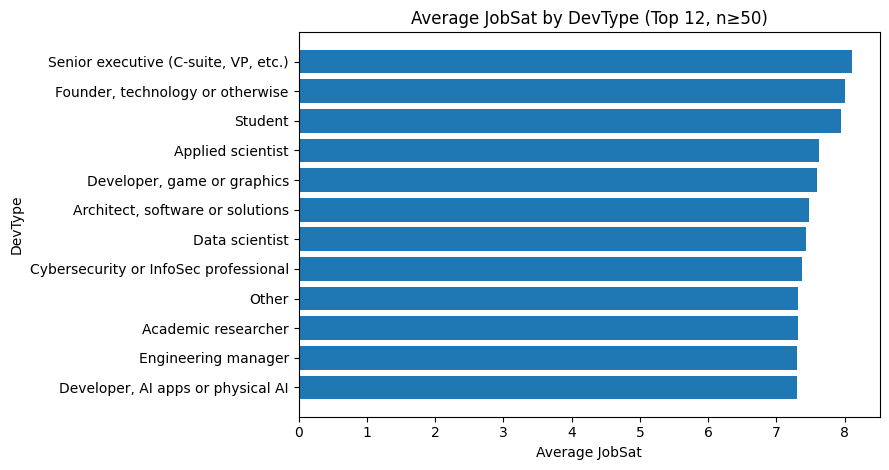

In [6]:
#Q1 - Average JobSat
job_sat_col = "JobSat"
devtype_col = "DevType"

work = df[[devtype_col, job_sat_col]].dropna().copy()
work = work.assign(DevType_single=work[devtype_col].str.split(";")).explode("DevType_single")
work["DevType_single"] = work["DevType_single"].str.strip()

summary = (work.groupby("DevType_single")[job_sat_col]
           .agg(mean="mean", n="count")
           .query("n >= 50")
           .sort_values("mean", ascending=False)
           .head(12)
           .sort_values("mean"))

plt.figure(figsize=(9,4.8))
plt.barh(summary.index, summary["mean"])
plt.xlabel("Average JobSat")
plt.ylabel("DevType")
plt.title("Average JobSat by DevType (Top 12, n≥50)")
plt.tight_layout()
plt.show()


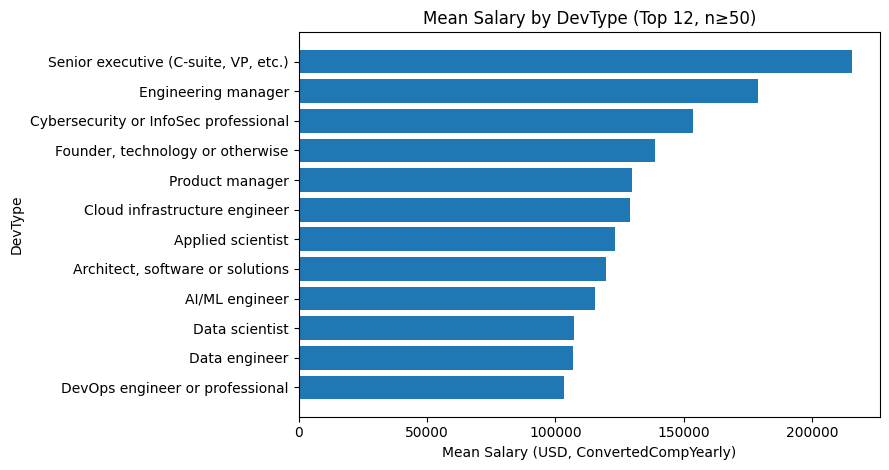

In [7]:
#Q1 - Mean Salary by DevType
salary_col = "ConvertedCompYearly"


work = df[[devtype_col, salary_col]].dropna().copy()

# 2)
work = work.assign(DevType_single=work[devtype_col].astype(str).str.split(";")).explode("DevType_single")
work["DevType_single"] = work["DevType_single"].str.strip()
work = work.dropna(subset=["DevType_single"])

# 3)
summary_salary = (work.groupby("DevType_single")[salary_col]
                 .agg(mean="mean", median="median", n="count")
                 .sort_values("mean", ascending=False))

# 4)
MIN_N = 50
TOP_N = 12

plot_df = (summary_salary[summary_salary["n"] >= MIN_N]
           .head(TOP_N)
           .sort_values("mean"))

plt.figure(figsize=(9, 4.8))
plt.barh(plot_df.index, plot_df["mean"])
plt.xlabel("Mean Salary (USD, ConvertedCompYearly)")
plt.ylabel("DevType")
plt.title(f"Mean Salary by DevType (Top {TOP_N}, n≥{MIN_N})")
plt.tight_layout()
plt.show()

Rows used: 20395
Salary 1% quantile: 654.52
Salary 99% quantile: 440856.0


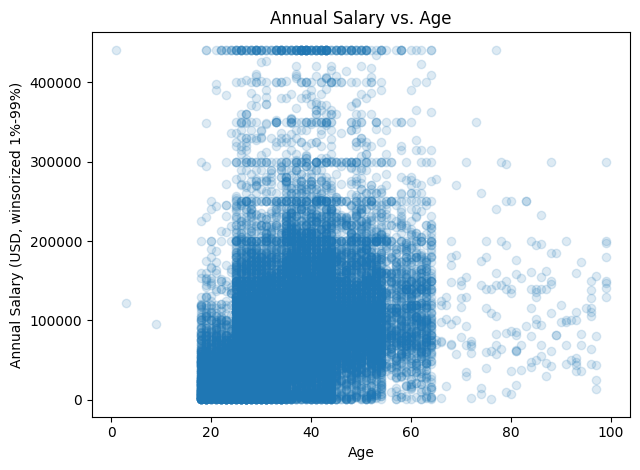

In [8]:
#Q1 - Annual Salary

age_col = "Age"

work = df[[age_col, salary_col]].dropna().copy()


work[age_col] = pd.to_numeric(work[age_col], errors="coerce")
work[salary_col] = pd.to_numeric(work[salary_col], errors="coerce")
work = work.dropna()


work = work[(work[age_col] > 0) & (work[age_col] < 100) & (work[salary_col] > 0)]

low, high = work[salary_col].quantile([0.01, 0.99])
work["Salary_w"] = work[salary_col].clip(lower=low, upper=high)

print("Rows used:", len(work))
print("Salary 1% quantile:", low)
print("Salary 99% quantile:", high)

plt.figure(figsize=(6.5, 4.8))
plt.scatter(work[age_col], work["Salary_w"], alpha=0.15)
plt.xlabel("Age")
plt.ylabel("Annual Salary (USD, winsorized 1%-99%)")
plt.title("Annual Salary vs. Age")
plt.tight_layout()

In [9]:
#Q2 - Hybrid vs Remote

remote_col = "RemoteWork"
salary_col = "ConvertedCompYearly"

# Inspection
print(df[remote_col].value_counts(dropna=False).head(20))
print("\nUnique values:", df[remote_col].dropna().unique()[:20])



RemoteWork
Hybrid                         7803
Remote                         6934
In-person                      2993
Your choice (very flexible)    2677
Name: count, dtype: int64

Unique values: ['Remote' 'Hybrid' 'Your choice (very flexible)' 'In-person']


In [10]:
#Filtering for just Hybrid and Remote
tmp = df[[remote_col, salary_col]].dropna().copy()

#convert to lower case
rw = tmp[remote_col].astype(str).str.lower()

tmp = tmp[tmp[remote_col].isin(['Hybrid', 'Remote'])]

tmp = tmp.rename(columns={remote_col: 'Mode'})


print("\nAfter filtering:")
print(tmp['Mode'].value_counts())



After filtering:
Mode
Hybrid    7803
Remote    6934
Name: count, dtype: int64


In [11]:
desc = (tmp.groupby("Mode")[salary_col]
        .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
       )

print(desc)


         count           mean            std    min       1%      5%      25%  \
Mode                                                                            
Hybrid  7803.0  101790.277714  347264.838390  104.0  1162.44  7656.1  47566.0   
Remote  6934.0  118683.779781  442809.918435  102.0   614.65  4199.8  47650.0   

            50%       75%        95%       99%         max  
Mode                                                        
Hybrid  77730.0  116015.0  220000.00  400000.0  18387548.0  
Remote  90527.5  150000.0  257584.15  500000.0  33552715.0  


<Figure size 700x400 with 0 Axes>

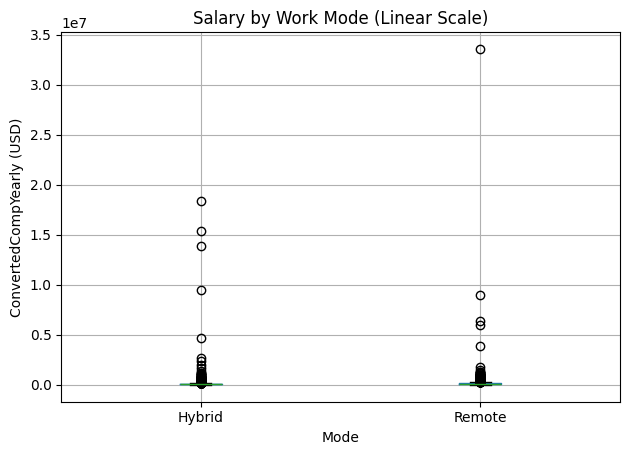

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
tmp.boxplot(column=salary_col, by="Mode")
plt.title("Salary by Work Mode (Linear Scale)")
plt.suptitle("")
plt.xlabel("Mode")
plt.ylabel("ConvertedCompYearly (USD)")
plt.tight_layout()
plt.show()

In [13]:
# Remove Outliers
q_low = tmp[salary_col].quantile(0.01)
q_high = tmp[salary_col].quantile(0.99)

print("Outlier bounds:", q_low, q_high)

tmp = tmp[(tmp[salary_col] >= q_low) & (tmp[salary_col] <= q_high)].copy()


print(f"Rows remaining after removing outliers: {len(tmp)}")
print(tmp.groupby("Mode")[salary_col].describe())

Outlier bounds: 848.4000000000002 450000.0
Rows remaining after removing outliers: 14445
         count           mean           std    min      25%      50%  \
Mode                                                                   
Hybrid  7681.0   89552.273011  63554.316646  858.0  48000.0  77730.0   
Remote  6764.0  104783.717771  75873.341567  863.0  48726.0  90793.5   

             75%       max  
Mode                        
Hybrid  116015.0  450000.0  
Remote  150000.0  450000.0  


In [14]:
#Q2b - manual calculation of t-test(Mean, std)


use_col = salary_col


hy = tmp.loc[tmp["Mode"] == "Hybrid", use_col].dropna().to_numpy()
re = tmp.loc[tmp["Mode"] == "Remote", use_col].dropna().to_numpy()

#sample size
n1, n2 = len(hy), len(re)
#sample mean
m1, m2 = hy.mean(), re.mean()
#sample variance
v1, v2 = hy.var(ddof=1), re.var(ddof=1)

print("Hybrid n, mean, var:", n1, m1, v1)
print("Remote n, mean, var:", n2, m2, v2)
print("Mean diff (Hybrid - Remote):", m1 - m2)

Hybrid n, mean, var: 7681 89552.27301132664 4039151164.2873034
Remote n, mean, var: 6764 104783.71777054996 5756763960.504838
Mean diff (Hybrid - Remote): -15231.44475922332


In [15]:
# Calculate Standard Deviation for current data
sd_hybrid = hy.std(ddof=1)
sd_remote = re.std(ddof=1)

print(f"Hybrid SD: {sd_hybrid:,.2f}")
print(f"Remote SD: {sd_remote:,.2f}")

Hybrid SD: 63,554.32
Remote SD: 75,873.34


In [16]:
#Q2 - manual calculation of t-test

import numpy as np

# pooled variance & pooled std
sp2 = ((n1 - 1)*v1 + (n2 - 1)*v2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# t statistic
t_manual = (m1 - m2) / (sp * np.sqrt(1/n1 + 1/n2))
dfree = n1 + n2 - 2

print("sp^2:", sp2)
print("sp:", sp)
print("t_manual:", t_manual)
print("df:", dfree)


sp^2: 4843431115.877637
sp: 69594.76356650432
t_manual: -13.125517788994546
df: 14443


In [59]:
#Levene

stat_levene, p_levene = stats.levene(hy, re, center="median")
print("Levene test p-value:", p_levene)


Levene test p-value: 2.3838438562672127e-60


In [17]:
# t test conparsion

from scipy import stats

#Python's built-in t-test
t_eq, p_eq = stats.ttest_ind(hy, re, equal_var=True)
t_w, p_w = stats.ttest_ind(hy, re, equal_var=False)  # Welch

print("SciPy equal_var=True:  t =", t_eq, " p =", p_eq)
print("SciPy Welch (equal_var=False): t =", t_w, " p =", p_w)


SciPy equal_var=True:  t = -13.125517788994546  p = 3.938290685612911e-39
SciPy Welch (equal_var=False): t = -12.980212390474714  p = 2.712014302764707e-38


In [19]:
#2c Bootstrap & plot

import numpy as np
import matplotlib.pyplot as plt

salary_col = "ConvertedCompYearly"
use_col = salary_col

hy = tmp.loc[tmp["Mode"] == "Hybrid", use_col].dropna().to_numpy()
re = tmp.loc[tmp["Mode"] == "Remote", use_col].dropna().to_numpy()

n1, n2 = len(hy), len(re)
print("Hybrid n =", n1, "| Remote n =", n2)

# observed diff
obs_diff = hy.mean() - re.mean()
print("Observed mean diff (Hybrid - Remote) =", obs_diff)

# Bootstrap：relative to its size
B = 10_000
rng = np.random.default_rng(42)

boot_mean_hy = np.empty(B)
boot_mean_re = np.empty(B)

for b in range(B):
    boot_mean_hy[b] = rng.choice(hy, size=n1, replace=True).mean()
    boot_mean_re[b] = rng.choice(re, size=n2, replace=True).mean()

boot_diff = boot_mean_hy - boot_mean_re

# z-score
boot_diff_std = (boot_diff - boot_diff.mean()) / boot_diff.std(ddof=1)

print("Bootstrap diff mean:", boot_diff.mean())
print("Bootstrap diff std :", boot_diff.std(ddof=1))

Hybrid n = 7681 | Remote n = 6764
Observed mean diff (Hybrid - Remote) = -15231.44475922332
Bootstrap diff mean: -15218.094984240228
Bootstrap diff std : 1174.6091183428869


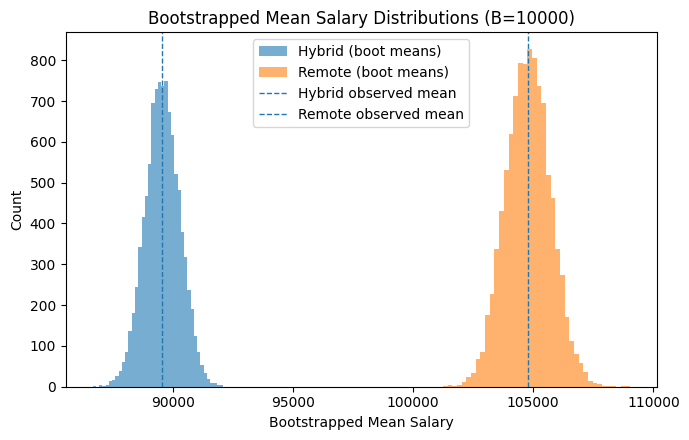

In [20]:
#  Figure 1: two bootstrapped distributions (for hybrid and remote job modes)
plt.figure(figsize=(7,4.5))
plt.hist(boot_mean_hy, bins=40, alpha=0.6, label="Hybrid (boot means)")
plt.hist(boot_mean_re, bins=40, alpha=0.6, label="Remote (boot means)")
plt.axvline(hy.mean(), linestyle="--", linewidth=1, label="Hybrid observed mean")
plt.axvline(re.mean(), linestyle="--", linewidth=1, label="Remote observed mean")
plt.xlabel("Bootstrapped Mean Salary")
plt.ylabel("Count")
plt.title(f"Bootstrapped Mean Salary Distributions (B={B})")
plt.legend()
plt.tight_layout()
plt.show()



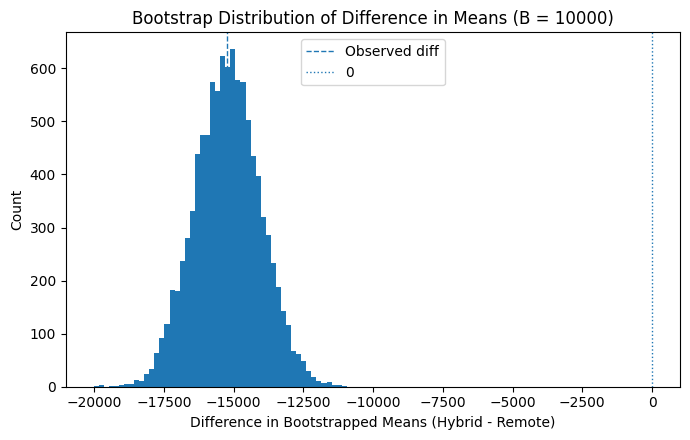

In [24]:
#  Figure 2: the distribution of the difference in means
plt.figure(figsize=(7,4.5))
plt.hist(boot_diff, bins=50)
plt.axvline(obs_diff, linestyle="--", linewidth=1, label="Observed diff")
plt.axvline(0, linestyle=":", linewidth=1, label="0")
plt.xlabel("Difference in Bootstrapped Means (Hybrid - Remote)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Difference in Means (B = 10000)")
plt.legend()
plt.tight_layout()
plt.show()


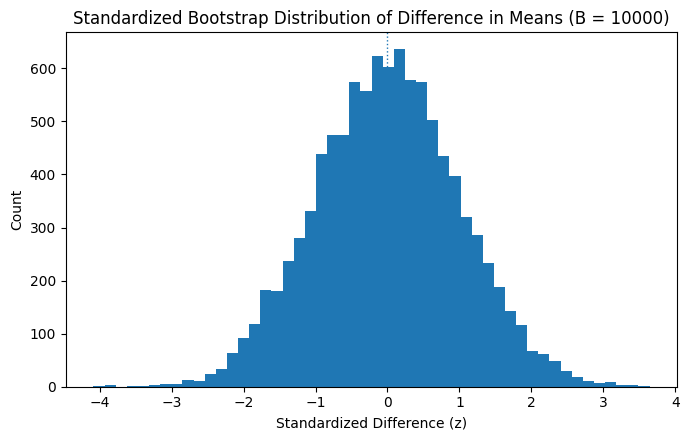

In [25]:
#Figure 3: the standardized distribution of the difference in means
plt.figure(figsize=(7,4.5))
plt.hist(boot_diff_std, bins=50)
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Standardized Difference (z)")
plt.ylabel("Count")
plt.title("Standardized Bootstrap Distribution of Difference in Means (B = 10000)")
plt.tight_layout()
plt.show()

In [26]:
#2d：Bootstrap t-test（α=0.05）+ p-value

import numpy as np
from scipy import stats

alpha = 0.05

boot_diff_null = boot_diff - boot_diff.mean()

#two-sided p-value
p_boot = np.mean(np.abs(boot_diff_null) >= np.abs(obs_diff))


se_boot = boot_diff.std(ddof=1)
t_boot = obs_diff / se_boot

print("Bootstrap SE (std of boot_diff):", se_boot)
print("Bootstrap t/z statistic (obs_diff / SE):", t_boot)
print("Bootstrap two-sided p-value:", p_boot)



Bootstrap SE (std of boot_diff): 1174.6091183428869
Bootstrap t/z statistic (obs_diff / SE): -12.96724546180223
Bootstrap two-sided p-value: 0.0


In [27]:
#2e：95% CI


import numpy as np
from scipy import stats

alpha = 0.05
conf = 1 - alpha

n1, n2 = len(hy), len(re)
m1, m2 = hy.mean(), re.mean()
v1, v2 = hy.var(ddof=1), re.var(ddof=1)

diff = m1 - m2  # Hybrid - Remote

# Welch SE & df
se_welch = np.sqrt(v1/n1 + v2/n2)
df_welch = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
tcrit_w = stats.t.ppf(1 - alpha/2, df_welch)
ci_welch = (diff - tcrit_w*se_welch, diff + tcrit_w*se_welch)

# PooledVar
sp2 = ((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2)
se_pooled = np.sqrt(sp2*(1/n1 + 1/n2))
df_pooled = n1 + n2 - 2
tcrit_p = stats.t.ppf(1 - alpha/2, df_pooled)
ci_pooled = (diff - tcrit_p*se_pooled, diff + tcrit_p*se_pooled)


print(f"Welch CI:  [{ci_welch[0]:.2f}, {ci_welch[1]:.2f}]  (df≈{df_welch:.1f})")
print(f"Pooled CI: [{ci_pooled[0]:.2f}, {ci_pooled[1]:.2f}]  (df={df_pooled})")


# Bootstrap 95% CI
ci_boot = (np.percentile(boot_diff, 2.5), np.percentile(boot_diff, 97.5))
print(f"Bootstrap CI: [{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]  (B={len(boot_diff)})")


Welch CI:  [-17531.55, -12931.34]  (df≈13248.3)
Pooled CI: [-17506.07, -12956.82]  (df=14443)
Bootstrap CI: [-17482.77, -12922.68]  (B=10000)


In [29]:
# 2f（Mood’s median test + bootstrap median p-value）
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Mood’s median test

stat, p_mood, grand_median, table = stats.median_test(hy, re)
print("Grand median:", grand_median)
print("Test statistic:", stat)
print("p-value:", p_mood)
print("Contingency table (above/below grand median):\n", table)


obs_med_diff = np.median(hy) - np.median(re)
print("\nObserved median diff (Hybrid - Remote):", obs_med_diff)


#Bootstrap medians + two-sided p-value for median difference

B = 10_000
rng = np.random.default_rng(42)

n1, n2 = len(hy), len(re)
boot_med_hy = np.empty(B)
boot_med_re = np.empty(B)

for b in range(B):
    boot_med_hy[b] = np.median(rng.choice(hy, size=n1, replace=True))
    boot_med_re[b] = np.median(rng.choice(re, size=n2, replace=True))

boot_med_diff = boot_med_hy - boot_med_re

boot_med_diff_null = boot_med_diff - boot_med_diff.mean()

p_boot_med = np.mean(np.abs(boot_med_diff_null) >= np.abs(obs_med_diff))

print("Bootstrap median diff mean:", boot_med_diff.mean())
print("Bootstrap median diff std :", boot_med_diff.std(ddof=1))
print("Bootstrap two-sided p-value (H0: diff=0):", p_boot_med)

Grand median: 81920.0
Test statistic: 112.98305518819633
p-value: 2.1762679382718212e-26
Contingency table (above/below grand median):
 [[3521 3701]
 [4160 3063]]

Observed median diff (Hybrid - Remote): -13063.5
Bootstrap median diff mean: -13249.12245
Bootstrap median diff std : 1582.129637766788
Bootstrap two-sided p-value (H0: diff=0): 0.0


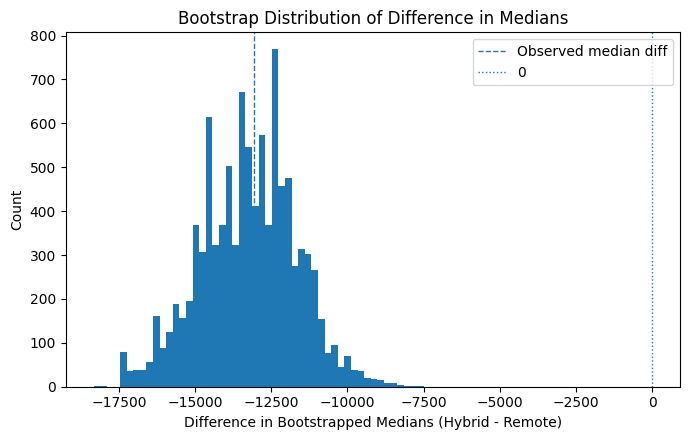

In [30]:
plt.figure(figsize=(7,4.5))
plt.hist(boot_med_diff, bins=50)
plt.axvline(obs_med_diff, linestyle="--", linewidth=1, label="Observed median diff")
plt.axvline(0, linestyle=":", linewidth=1, label="0")
plt.xlabel("Difference in Bootstrapped Medians (Hybrid - Remote)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Difference in Medians")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
#Q3 prepare：select North America（US + Canada）and extract three groups of edu level

salary_col = "ConvertedCompYearly"
country_col = "Country"
edu_col = "EdLevel"
salary_col = "ConvertedCompYearly"

na = df[[country_col, edu_col, salary_col]].dropna().copy()

# only keep US + Canada
na = na[na[country_col].isin(["United States of America", "Canada"])].copy()
print("North America rows:", len(na))
print("Countries:\n", na[country_col].value_counts())

edu = na[edu_col].astype(str).str.lower()

na["EduGroup"] = np.nan
na.loc[edu.str.contains("bachelor", na=False), "EduGroup"] = "Bachelor"
na.loc[edu.str.contains("master", na=False), "EduGroup"] = "Master"
na.loc[edu.str.contains("professional", na=False), "EduGroup"] = "Professional"

na = na.dropna(subset=["EduGroup"]).copy()
print("\nEduGroup counts:\n", na["EduGroup"].value_counts())
na.head()

North America rows: 5468
Countries:
 Country
United States of America    4679
Canada                       789
Name: count, dtype: int64

EduGroup counts:
 EduGroup
Bachelor        2978
Master          1084
Professional     301
Name: count, dtype: int64


/tmp/ipython-input-2149983766.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bachelor' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  na.loc[edu.str.contains("bachelor", na=False), "EduGroup"] = "Bachelor"


,Country,EdLevel,ConvertedCompYearly,EduGroup
11,United States of America,Master's degree,205000,Master
12,United States of America,Bachelor's degree,250000,Bachelor
13,United States of America,Bachelor's degree,175000,Bachelor
15,United States of America,Master's degree,109000,Master
17,United States of America,Bachelor's degree,150000,Bachelor


In [32]:
#3a: desciprtive + outlier handleing
desc3 = (na.groupby("EduGroup")[salary_col]
         .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
desc3


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
EduGroup,,,,,,,,,,,,
Bachelor,2978.0,160987.604433,113742.423728,126.0,10819.22,55000.0,100000.0,140000.0,190000.0,330000.0,587423.59,1950000.0
Master,1084.0,182220.476937,161910.830185,125.0,380.45,47150.0,110750.0,157000.0,215000.0,369250.0,646150.00,3900000.0
Professional,301.0,197700.960133,194866.381460,185.0,2000.00,56680.0,108000.0,160000.0,217000.0,450000.0,900000.00,2346000.0


<Figure size 700x400 with 0 Axes>

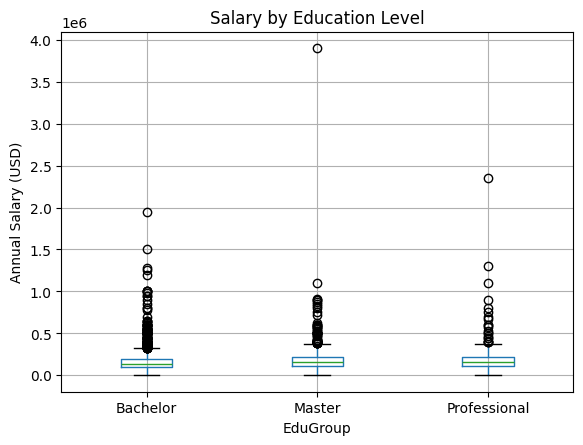

In [37]:
#visualize the outliers
plt.figure(figsize=(7,4))
na.boxplot(column=salary_col, by="EduGroup")
plt.title("Salary by Education Level")
plt.suptitle("")
plt.ylabel("Annual Salary (USD)")
plt.show()

In [ ]:
# Winsorize at 1%-99% quantiles
"""due to small sample size, we should not reomove outliers"""
q_low, q_high = na[salary_col].quantile([0.01, 0.99])
na["salary_eduW"] = na[salary_col].clip(q_low, q_high)

print(f"Lower bound: ${q_low:.2f}")
print(f"Upper bound: ${q_high:.2f}")

desc3_winsorized = (na.groupby("EduGroup")["salary_eduW"]
                    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
desc3_winsorized

Lower bound: $7981.76
Upper bound: $600000.00


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
EduGroup,,,,,,,,,,,,
Bachelor,2978.0,158256.953741,93384.244030,7981.76,10819.22,55000.0,100000.0,140000.0,190000.0,330000.0,587423.59,600000.0
Master,1084.0,176813.236310,103717.282724,7981.76,7981.76,47150.0,110750.0,157000.0,215000.0,369250.0,600000.00,600000.0
Professional,301.0,185269.159601,120323.798678,7981.76,7981.76,56680.0,108000.0,160000.0,217000.0,450000.0,600000.00,600000.0


In [ ]:
#3b) ANOVA
salary_col = "ConvertedCompYearly"
use_col = "salary_eduW"

bach = na.loc[na["EduGroup"] == "Bachelor", use_col].dropna().to_numpy()
mast = na.loc[na["EduGroup"] == "Master", use_col].dropna().to_numpy()
prof = na.loc[na["EduGroup"] == "Professional", use_col].dropna().to_numpy()

print("Group sizes:", len(bach), len(mast), len(prof))
print("Group means:", np.mean(bach), np.mean(mast), np.mean(prof))

#ANOVA（F-test）
F_obs, p_obs = stats.f_oneway(bach, mast, prof)
print("ANOVA F:", F_obs)
print("ANOVA p-value:", p_obs)



Group sizes: 2978 1084 301
Group means: 158256.95374076563 176813.2363099631 185269.1596013289
ANOVA F: 21.30531478233761
ANOVA p-value: 6.196422091876128e-10


In [ ]:
#3c - Bootstrap


B = 10000
rng = np.random.default_rng(42)

nB, nM, nP = len(bach), len(mast), len(prof)
print("Group sizes (B, M, P):", nB, nM, nP)

boot_B = np.empty(B)
boot_M = np.empty(B)
boot_P = np.empty(B)

for b in range(B):
    boot_B[b] = rng.choice(bach, size=nB, replace=True).mean()
    boot_M[b] = rng.choice(mast, size=nM, replace=True).mean()
    boot_P[b] = rng.choice(prof, size=nP, replace=True).mean()

# pairwise mean difference
diff_BM = boot_B - boot_M
diff_BP = boot_B - boot_P
diff_MP = boot_M - boot_P

def zscore(x):
    return (x - x.mean()) / x.std(ddof=1)

z_BM, z_BP, z_MP = zscore(diff_BM), zscore(diff_BP), zscore(diff_MP)
print("Observed means (winsorized):",
      np.mean(bach), np.mean(mast), np.mean(prof))
print("Bootstrap mean diffs (mean):",
      diff_BM.mean(), diff_BP.mean(), diff_MP.mean())


Group sizes (B, M, P): 2978 1084 301
Observed means (winsorized): 158256.95374076563 176813.2363099631 185269.1596013289
Bootstrap mean diffs (mean): -18626.641710808806 -26911.629546955646 -8284.98783614684


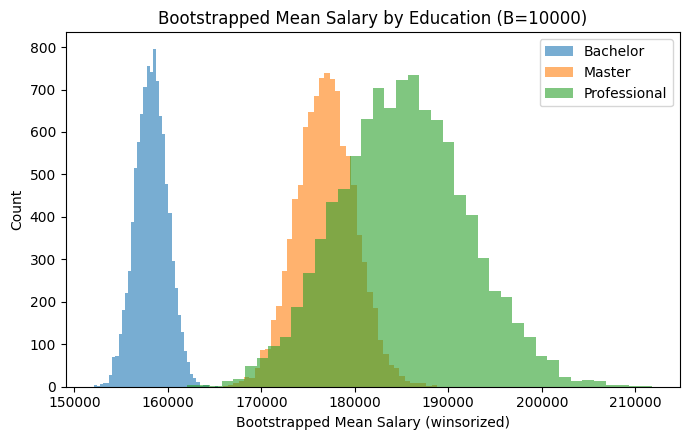

In [51]:
# Figure 1: three bootstrapped distributions,
plt.figure(figsize=(7,4.5))
plt.hist(boot_B, bins=40, alpha=0.6, label="Bachelor")
plt.hist(boot_M, bins=40, alpha=0.6, label="Master")
plt.hist(boot_P, bins=40, alpha=0.6, label="Professional")
plt.xlabel("Bootstrapped Mean Salary (winsorized)")
plt.ylabel("Count")
plt.title(f"Bootstrapped Mean Salary by Education (B={B})")
plt.legend()
plt.tight_layout()
plt.show()

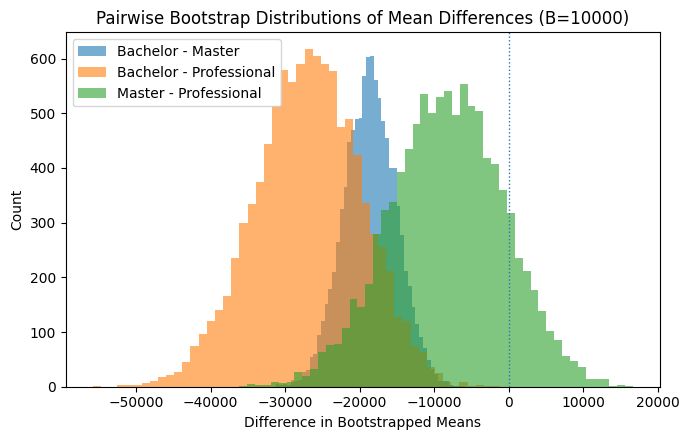

In [52]:
#Figure 2: pairwise difference in means
plt.figure(figsize=(7,4.5))
plt.hist(diff_BM, bins=50, alpha=0.6, label="Bachelor - Master")
plt.hist(diff_BP, bins=50, alpha=0.6, label="Bachelor - Professional")
plt.hist(diff_MP, bins=50, alpha=0.6, label="Master - Professional")
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Difference in Bootstrapped Means")
plt.ylabel("Count")
plt.title("Pairwise Bootstrap Distributions of Mean Differences (B=10000)")
plt.legend()
plt.tight_layout()
plt.show()


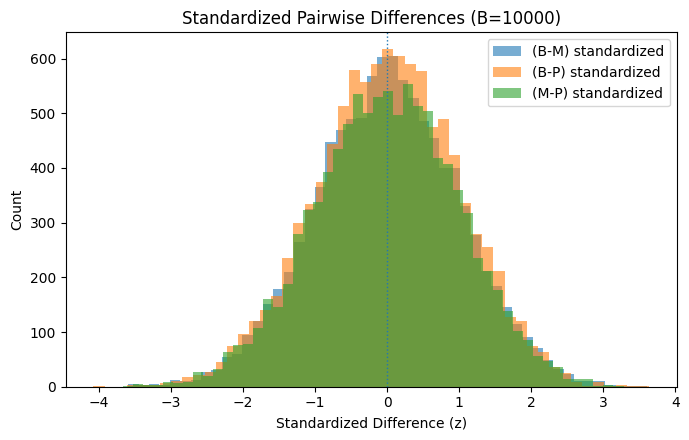

In [53]:
#Figure 3: standardized pairwise differences
plt.figure(figsize=(7,4.5))
plt.hist(z_BM, bins=50, alpha=0.6, label="(B-M) standardized")
plt.hist(z_BP, bins=50, alpha=0.6, label="(B-P) standardized")
plt.hist(z_MP, bins=50, alpha=0.6, label="(M-P) standardized")
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Standardized Difference (z)")
plt.ylabel("Count")
plt.title("Standardized Pairwise Differences (B=10000)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#3d

alpha = 0.05

F_obs, p_classical = stats.f_oneway(bach, mast, prof)
print("Observed F:", F_obs)
print("Classical ANOVA p:", p_classical)

# H0
grand_mean = np.mean(np.concatenate([bach, mast, prof]))

bach0 = bach - np.mean(bach) + grand_mean
mast0 = mast - np.mean(mast) + grand_mean
prof0 = prof - np.mean(prof) + grand_mean

B = 10_000
rng = np.random.default_rng(42)
F_null = np.empty(B)

for b in range(B):
    sB = rng.choice(bach0, size=len(bach0), replace=True)
    sM = rng.choice(mast0, size=len(mast0), replace=True)
    sP = rng.choice(prof0, size=len(prof0), replace=True)
    F_null[b] = stats.f_oneway(sB, sM, sP).statistic

p_boot_anova = np.mean(F_null >= F_obs)
print("Bootstrap ANOVA p (null-shift):", p_boot_anova)


Observed F: 21.30531478233761
Classical ANOVA p: 6.196422091876128e-10
Bootstrap ANOVA p (null-shift): 0.0


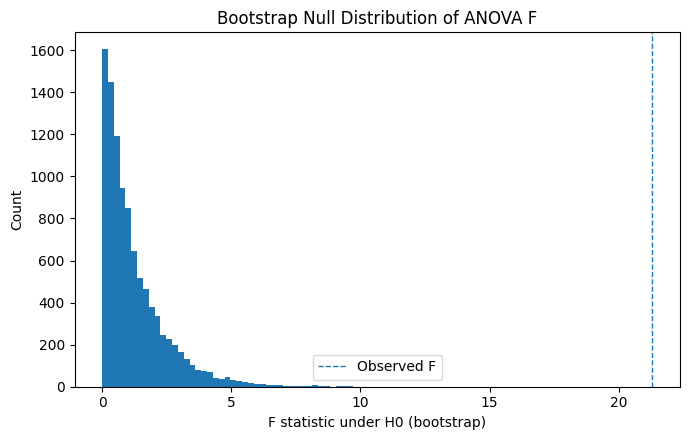

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4.5))
plt.hist(F_null, bins=50)
plt.axvline(F_obs, linestyle="--", linewidth=1, label="Observed F")
plt.xlabel("F statistic under H0 (bootstrap)")
plt.ylabel("Count")
plt.title("Bootstrap Null Distribution of ANOVA F")
plt.legend()
plt.tight_layout()
plt.show()
